Exercício 1

a) 10 primeiros valores: [5, 30, 17, 2, 29, 6, 9, 10, 21, 14, 1]
b) Período encontrado: 16
c) Possui período máximo? False


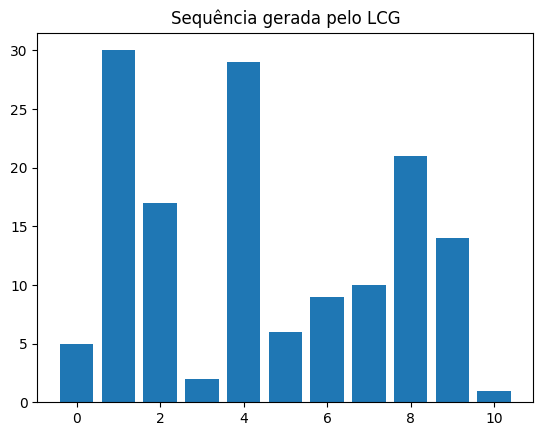

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Parâmetros
a = 11
c = 7
m = 32
X0 = 5

# a) gerar os n primeiros valores
n = 10
x_vals = [X0]

x = X0
for i in range(n):
    x = (a * x + c) % m
    x_vals.append(x)

print("a) 10 primeiros valores:", x_vals)

# b) determinar o período
# gerando até que x0 se repita
x = X0
sequencia = [x]
while True:
    x = (a * x + c) % m
    if x == X0:
        break
    sequencia.append(x)

periodo = len(sequencia)
print("b) Período encontrado:", periodo)

# c) verificar se o período é máximo (que seria m)
periodo_maximo = (periodo == m)
print("c) Possui período máximo?", periodo_maximo)

# d) Gráfico dos primeiros valores
ind = np.arange(len(x_vals))
plt.bar(ind, x_vals)
plt.title("Sequência gerada pelo LCG")
plt.show()

# Exercício 2

In [3]:
import math

lambda1 = 4

# a) Probabilidade de ocorrerem exatamente 6 falhas
k = 6
P6 = math.exp(-lambda1) * (lambda1**k) / math.factorial(k)
print("a) P(X=6) =", P6)

# b) Probabilidade de ocorrerem no máximo 2 falhas
P_le2 = sum([math.exp(-lambda1) * (lambda1**i) / math.factorial(i) for i in range(3)])
print("b) P(X<=2) =", P_le2)

# c) Probabilidade de ocorrerem mais de 5 falhas em 2 horas (λ=4x2)
lambda2 = 2 * lambda1
P_le5 = sum([math.exp(-lambda2) * (lambda2**i) / math.factorial(i) for i in range(6)])
P_gt5 = 1 - P_le5
print("c) P(X>5) em 2h =", P_gt5)

# d) Valor esperado e variância
print("d) Valor esperado =", lambda1)
print("   Variância =", lambda1)

# Gerando N amostras
N = 100
amostras = np.array([])

x = np.random.uniform(0, 1, N)

for ix in x:
    i = 0
    pr = np.exp(-lambda1)
    F = pr

    while ix >= F:
        pr = lambda1/(i+1) * pr
        F = F + pr
        i = i + 1

    amostras = np.append(amostras, i)

print("\nAmostras Poisson geradas (100 valores):")
print(amostras)

a) P(X=6) = 0.1041956345670211
b) P(X<=2) = 0.2381033055535443
c) P(X>5) em 2h = 0.8087639379203747
d) Valor esperado = 4
   Variância = 4

Amostras Poisson geradas (100 valores):
[ 6.  2.  4.  7.  4.  3.  7.  6.  5.  6.  1.  1.  5.  5.  4.  2.  2.  2.
  8.  3.  5.  3.  3.  4.  4.  6.  1.  4.  2.  3.  2.  4.  3.  6.  3.  1.
  2.  1.  0.  6.  1. 10.  3.  3.  3.  4.  2.  1.  1.  1.  4.  1.  6.  5.
  5.  2.  3.  4.  2.  5.  4.  7.  3.  4.  2.  1.  4.  4.  2.  2.  1.  4.
  7.  2.  5.  4.  5.  1.  9.  3.  4.  4.  6.  7.  7.  5.  2.  6.  3.  2.
  2.  4.  4. 10.  6.  1.  7.  3.  6.  2.]


Exercício 3

In [7]:
import numpy as np
import math

# Parâmetros do exercício
p = 0.08
q = 1 - p
n = 20
N = 10
c = p / q

# a) P(X = 3)
P3 = math.comb(n, 3) * (p**3) * (q**(n-3))
print("a) P(X=3) =", P3)

# b) P(X <= 2)
P_le2 = sum([math.comb(n, k) * (p**k) * (q**(n-k)) for k in range(0, 3)])
print("b) P(X<=2) =", P_le2)

# c) P(X > 5)
P_le5 = sum([math.comb(n, k) * (p**k) * (q**(n-k)) for k in range(0, 6)])
P_gt5 = 1 - P_le5
print("c) P(X>5) =", P_gt5)

# d) Média e variância
media = n * p
variancia = n * p * q
print("d) Média =", media)
print("   Variância =", variancia)

# Geração de N amostras
av = np.array([])
x = np.random.uniform(0, 1, N)

for ix in x:
    i = 0
    # PMF inicial: P(0) = q^n
    pr = q**n
    F = pr

    # método da inversão
    while ix >= F:
        pr = (c * (n - i) / (i + 1)) * pr
        F += pr
        i += 1

    av = np.append(av, i)

print("\nAmostras geradas (binomial):")
print(av)

a) P(X=3) = 0.14143857663883505
b) P(X<=2) = 0.7879462459747031
c) P(X>5) = 0.0037994868343921295
d) Média = 1.6
   Variância = 1.4720000000000002

Amostras geradas (binomial):
[2. 0. 1. ... 2. 1. 2.]


Exercicio 4

In [5]:
import numpy as np
import math

# Parâmetros
p = 0.3
q = 1 - p
N = 10

# a) Simulação via método da inversão
amostras = np.array([])
x = np.random.uniform(0, 1, N)

for ix in x:
    i = 0
    pr = p
    F = pr

    while ix >= F:
        pr = q * pr
        F += pr
        i += 1

    amostras = np.append(amostras, i)

print("a) Amostras geradas (geométrica):")
print(amostras)

# b) P(X = 3)
P4 = (q**3) * p
print("\nb) P(1º sucesso na 4ª tentativa) =", P4)

# c) P(X > 6)
P_gt6 = q**7
print("c) P(X > 6) =", P_gt6)

# d) Média e variância
media = q/p
variancia = q/(p**2)

print("\nd) Média =", media)
print("   Variância =", variancia)

a) Amostras geradas (geométrica):
[1. 4. 3. 5. 2. 0. 0. 4. 6. 4.]

b) P(1º sucesso na 4ª tentativa) = 0.10289999999999998
c) P(X > 6) = 0.08235429999999996

d) Média = 2.3333333333333335
   Variância = 7.777777777777778


exercicio 5

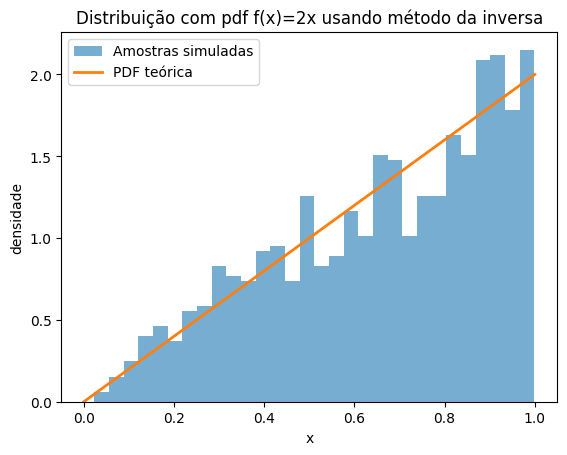

In [12]:
import numpy as np
import matplotlib.pyplot as plt

# (c) Métdo da inversa
N = 1000
U = np.random.uniform(0, 1, N)
X = np.sqrt(U)   # X = F^{-1}(U)

# Plot
x_vals = np.linspace(0, 1, 200)
pdf_vals = 2 * x_vals   # pdf teórica

plt.hist(X, bins=30, density=True, alpha=0.6, label='Amostras simuladas')
plt.plot(x_vals, pdf_vals, linewidth=2, label='PDF teórica')

plt.title('Distribuição com pdf f(x)=2x usando método da inversa')
plt.xlabel('x')
plt.ylabel('densidade')
plt.legend()
plt.show()